# EDA анализ

In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df_raw = pd.read_excel("../data/Данные_для_курсовои_Классическое_МО.xlsx")


print(f'Исходный shape: {df_raw.shape}')
display(df_raw.head())

Исходный shape: (1001, 214)


,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,...,0,0,0,0,0,0,0,0,3,0
1,1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,...,0,0,0,0,0,0,0,0,3,0
2,2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,...,0,0,0,0,0,0,0,0,3,0
3,3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,...,0,0,0,0,0,0,0,0,4,0
4,4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,...,0,0,0,0,0,0,0,0,0,0


## Шаг 1. Первичный обзор данных (размерность, типы признаков)

In [17]:
print(df_raw.dtypes.value_counts())

int64      107
float64    107
Name: count, dtype: int64


Все признаки числовые, что удобно для классических моделей

Видно колонку `Unnamed: 0`, она не несет ценности исключим ее  

In [18]:
df_raw = df_raw.drop(columns=["Unnamed: 0"])
df_raw.head()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,0


In [19]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Columns: 213 entries, IC50, mM to fr_urea
dtypes: float64(107), int64(106)
memory usage: 1.6 MB


### Вывод по шагу 1:
- все данные числовые 
- есть служебная колонка, которую мы отбросили
- итого в датасете осталось 1001 наблюдение и 213 признаков

## 2. Анализ дубликатов  и обработка пропусков

In [20]:
print("Количество дубликатов до удаления:", df_raw.duplicated().sum())
df_raw = df_raw.drop_duplicates()
print("Количество дубликатов после удаления:", df_raw.duplicated().sum())


Количество дубликатов до удаления: 32
Количество дубликатов после удаления: 0


In [21]:
missing = df_raw.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]

print(missing)   
    

MinAbsPartialCharge    3
MaxPartialCharge       3
MinPartialCharge       3
MaxAbsPartialCharge    3
BCUT2D_MWHI            3
BCUT2D_MRLOW           3
BCUT2D_MRHI            3
BCUT2D_LOGPLOW         3
BCUT2D_LOGPHI          3
BCUT2D_CHGLO           3
BCUT2D_CHGHI           3
BCUT2D_MWLOW           3
dtype: int64


Видно что пропуску есть но их немного, однако удалять их нельзя поскольку каждая строка это отдельное соединение, используем медианное заполнение

In [22]:
df_raw = df_raw.fillna(df_raw.median())
print(f"Осталось пропусков: {df_raw.isna().sum().sum()}")

Осталось пропусков: 0


In [23]:
df_raw.shape

(969, 213)

### Вывод по шагу 2:
- После удаления дубликатов и обработки пропусков у нас осталось 969 наблюдений и 213 признаков

## Шаг 3. Описательная статистика целевых переменных 

In [24]:
targets = ['IC50, mM', 'CC50, mM', 'SI']

desc_targets = df_raw[targets].describe().T
desc_targets["skew"] = df_raw[targets].skew()
display(desc_targets)


,count,mean,std,min,25%,50%,75%,max,skew
"IC50, mM",969.0,220.726223,397.172441,0.003517,12.515396,45.338355,231.373089,4128.529377,3.757993
"CC50, mM",969.0,586.419908,633.624464,0.700808,99.999345,424.166213,891.776925,4538.976189,1.996707
SI,969.0,73.967907,695.564665,0.011489,1.488095,3.900000,16.375000,15620.600000,17.728174


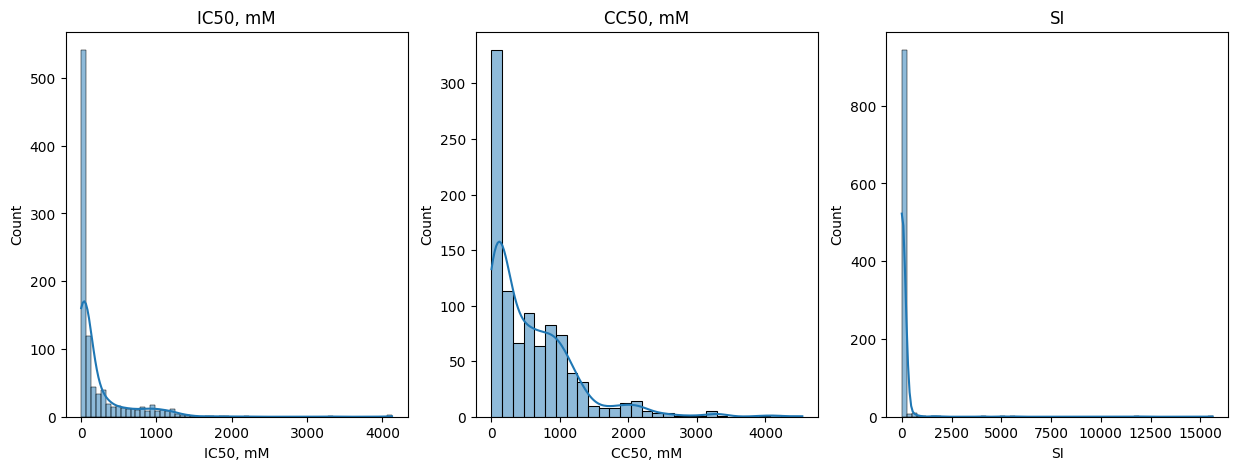

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, feature in enumerate(targets):
    sns.histplot(df_raw[feature], ax=axes[i], kde=True)
    axes[i].set_title(feature)

### Выводы по шагу 3:
- IC50, CC50 и особенно SI имеют большой разброс между квартилями и максимумами
- коэффициент ассиметрии > 0, что говорит о правосторонней ассиметрии 
- Типичное для биологических данных распределение: много умеренных значений, мало экстремальных.


## Шаг 4. Описательная статистика важных признаков

In [26]:
important_features = ['MolWt', 'TPSA', 'MolLogP', 'qed', 'NumHDonors', 'NumHAcceptors']
important_features = [c for c in important_features if c in df_raw.columns]

display(df_raw[important_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
MolWt,969.0,351.486139,127.388186,110.156000,266.252000,318.373000,413.670000,904.777000
TPSA,969.0,62.081950,45.980973,0.000000,29.460000,49.770000,83.760000,407.500000
MolLogP,969.0,3.452764,2.157542,-5.750700,2.449200,3.432800,4.537720,12.822200
qed,969.0,0.577633,0.213316,0.059567,0.442842,0.634372,0.742483,0.947265
NumHDonors,969.0,1.179567,1.604087,0.000000,0.000000,1.000000,2.000000,15.000000
NumHAcceptors,969.0,4.411765,3.220657,0.000000,2.000000,4.000000,5.000000,25.000000


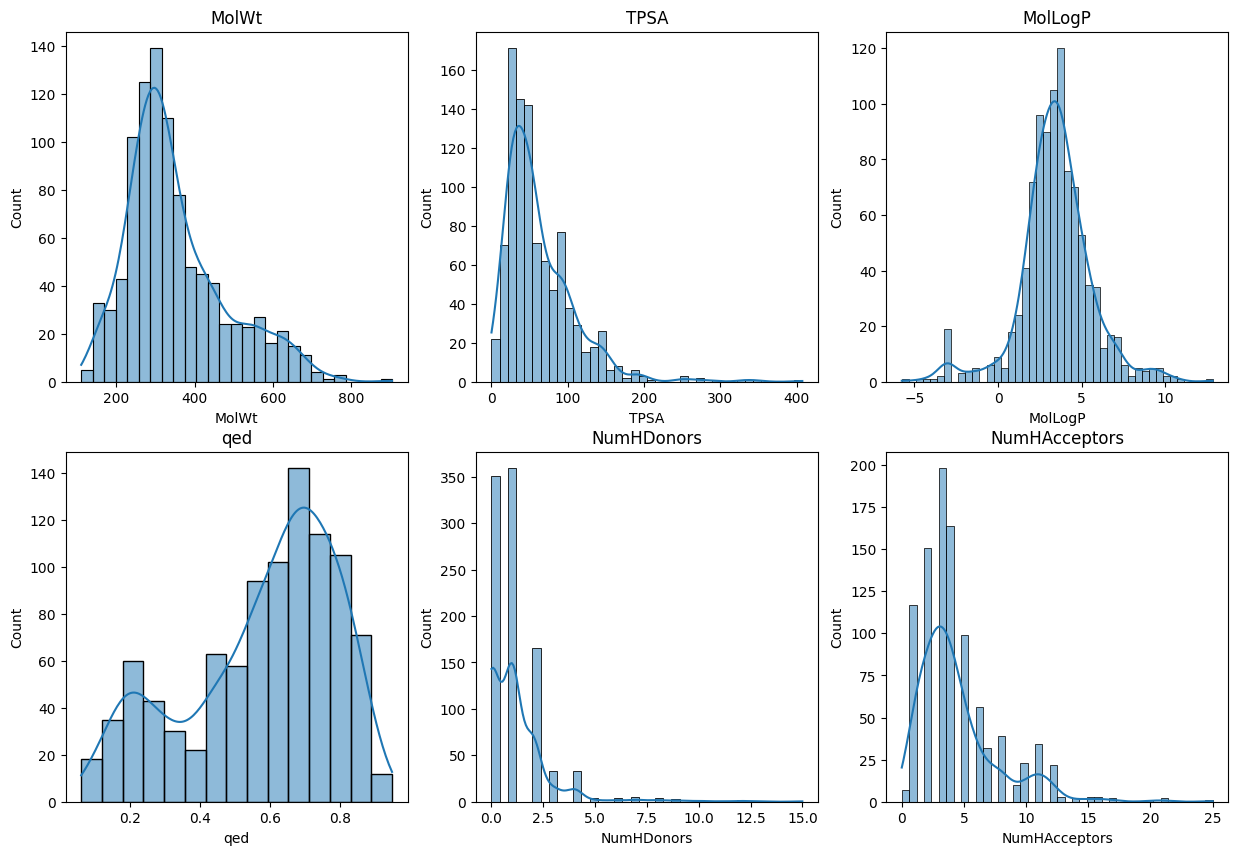

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, feature in enumerate(important_features):
    sns.histplot(df_raw[feature], ax=axes[i // 3, i % 3], kde=True)
    axes[i // 3, i % 3].set_title(feature)

### Вывод по шагу 4:
- признаки имеют разные масштабы и распределения, поэтому при использовании линейных моделей необходимо масштабирование



## Шаг 5: анализ выбросов

In [28]:
outlier_report = []
for t in targets:
    q1 = df_raw[t].quantile(0.25)
    q3 = df_raw[t].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    outlier_share = ((df_raw[t] < low) | (df_raw[t] > high)).mean()
    outlier_report.append(f"{t}: {outlier_share:.3f} ({int(outlier_share * len(df_raw))} шт.)")
    print(f"   {t}: доля выбросов = {outlier_share:.3f}")

   IC50, mM: доля выбросов = 0.142
   CC50, mM: доля выбросов = 0.036
   SI: доля выбросов = 0.124


## Шаг 6. Корреляционный анализ

<Axes: >

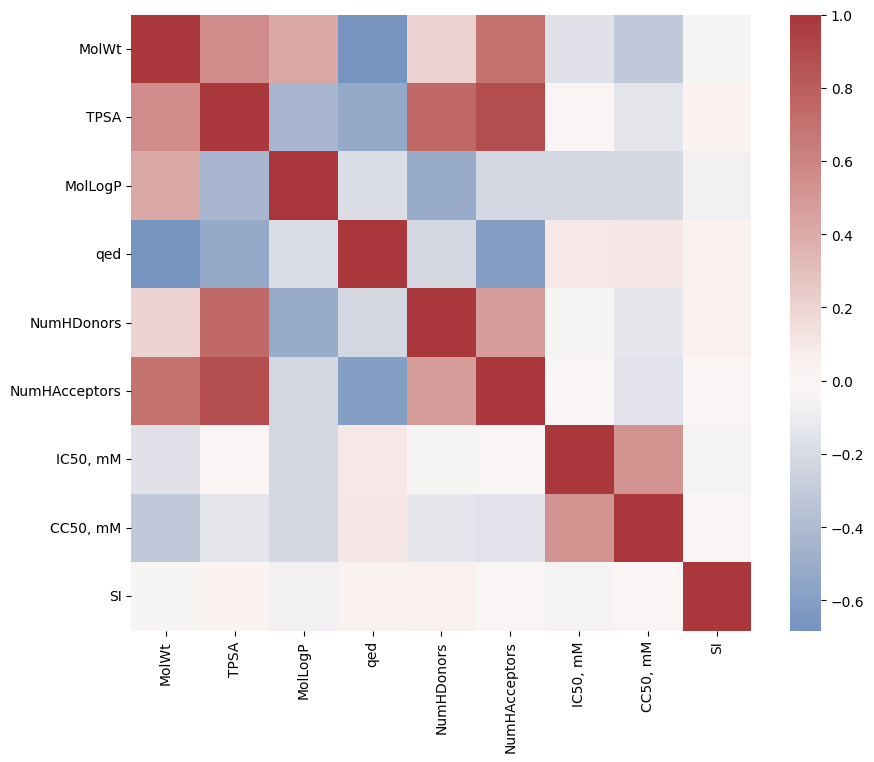

In [29]:
corr_matrix = df_raw.corr()
corr_with_targets = corr_matrix[targets].abs().drop(index=targets)
top_corr = {t: corr_with_targets[t].sort_values(ascending=False).head(10) for t in targets}
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix.loc[important_features + targets, important_features + targets], cmap='vlag', center=0, ax=ax)


### Вывод по шагу 6:
- построена корреляционная матрица по всем признакам
- выделены признаки с наибольшей связью с IC50, CC50 и SI
- визуализация помогает понять, какие признаки стоит рассматривать при построении модели

## Общий вывод по EDA

- Данные очищены: удалены дубликаты, заполнены пропуски медианой, итого 969 наблюдений и 213 признаков.
- Целевые переменные IC50, CC50, SI имеют скошенные распределения с выбросами (до 10-15%), что типично для биологических данных.
- Признаки разнородны по масштабу, требуется стандартизация для линейных моделей.
- Выявлены признаки с высокой корреляцией к целям (например, MolWt, TPSA, qed), которые стоит использовать в моделировании.
- Рекомендации: рассмотреть логарифмирование целей для снижения скошенности, применить feature selection на основе корреляций, учесть выбросы при обучении.

In [30]:
df_raw.to_csv("../data/df_clean.csv", index=False)